<a href="https://colab.research.google.com/github/RayaneRahmatErrahmaneSMARA/elevvoInternship/blob/main/Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# ===== Cell 1: Imports =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [30]:
# ===== Cell 2: Load & Quick Look =====
url = "https://raw.githubusercontent.com/PatrickJWalsh/Mall-Customer-Segmentation/refs/heads/master/Mall%20Customers.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [31]:
# ===== Cell 3: Focus on Key Features =====
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()
X.rename(columns={
    'Annual Income (k$)': 'Income',
    'Spending Score (1-100)': 'Spending'
}, inplace=True)

print("Selected Features:")
X.head()

Selected Features:


,Income,Spending
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [32]:
# ===== Cell 4: Scaling (Critical for Clustering!) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("First 5 scaled values:")
print(X_scaled[:5])

First 5 scaled values:
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


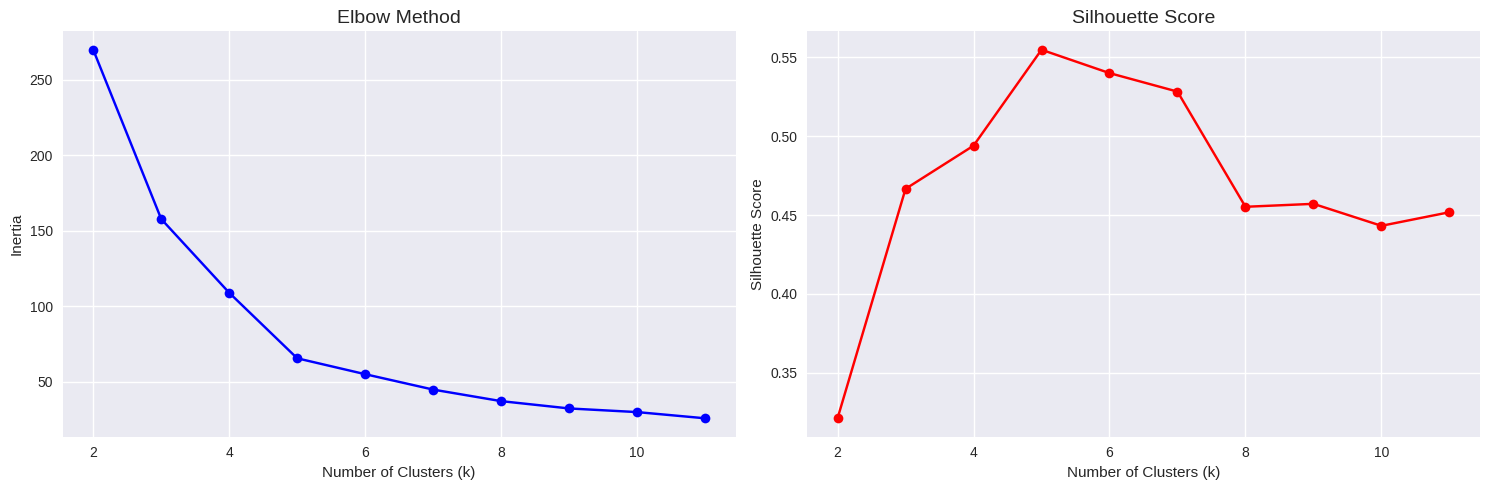

Best number of clusters by Silhouette Score: 5 (score = 0.555)


In [33]:
# ===== Cell 5: Find Optimal K (Elbow + Silhouette) =====
inertias = []
sil_scores = []
range_k = range(2, 12)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range_k, inertias, 'bo-')
ax1.set_title('Elbow Method', fontsize=14)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True)

ax2.plot(range_k, sil_scores, 'ro-')
ax2.set_title('Silhouette Score', fontsize=14)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print best k
best_k = range_k[np.argmax(sil_scores)]
print(f"Best number of clusters by Silhouette Score: {best_k} (score = {max(sil_scores):.3f})")

In [34]:
# ===== Cell 6: Final K-Means Model =====
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Centroids (for interpretation)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroid_df = pd.DataFrame(centroids, columns=['Income', 'Spending'])
print("Cluster Centroids (original scale):")
print(centroid_df.round(1))

Cluster Centroids (original scale):
   Income  Spending
0    55.3      49.5
1    86.5      82.1
2    25.7      79.4
3    88.2      17.1
4    26.3      20.9


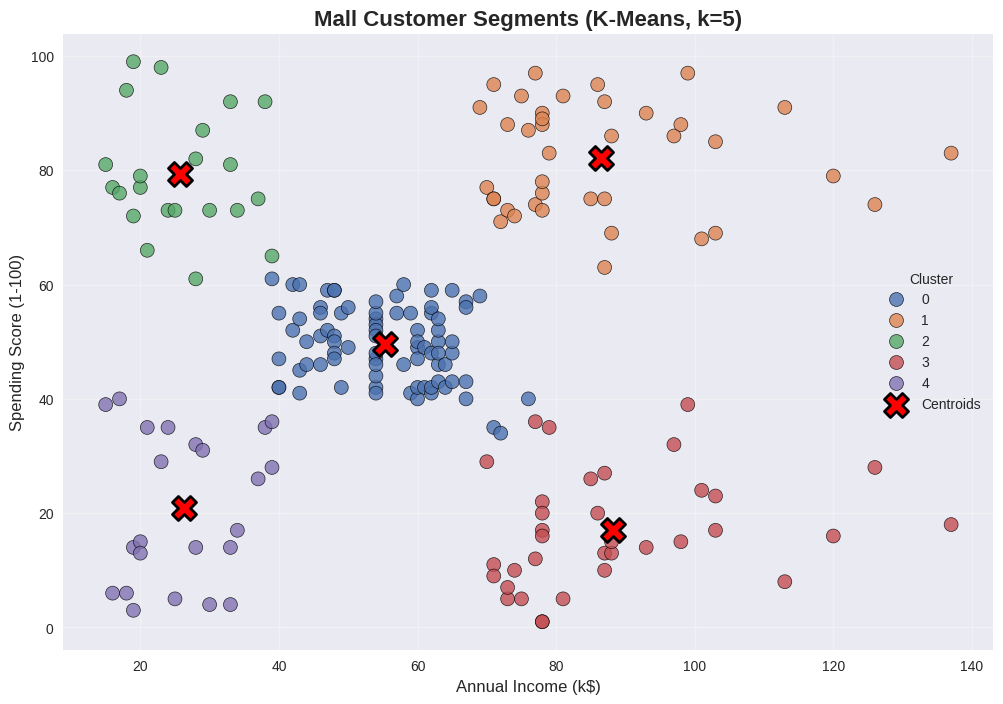

In [35]:
# ===== Cell 7: Beautiful Cluster Visualization =====
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='deep', s=100, alpha=0.8, edgecolor='k', linewidth=0.5
)
plt.scatter(centroid_df['Income'], centroid_df['Spending'],
            s=300, c='red', marker='X', label='Centroids', edgecolors='black', linewidth=2)

plt.title('Mall Customer Segments (K-Means, k=5)', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
# ===== Cell 8: Cluster Profiles =====
profile = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(1)

profile = profile.rename(columns={'CustomerID': 'Count'})
profile = profile.sort_values('Cluster')

# Add meaningful names!
cluster_names = {
    0: "Careful High Earners",
    1: "Wealthy Big Spenders",
    2: "Average Earners & Spenders",
    3: "Thrifty High Earners",
    4: "Low Income Big Spenders"
}
profile['Segment Name'] = profile.index.map(cluster_names)

print("CUSTOMER SEGMENTS SUMMARY")
print("="*60)
print(profile[['Segment Name', 'Count', 'Annual Income (k$)', 'Spending Score (1-100)']])

CUSTOMER SEGMENTS SUMMARY
                       Segment Name  Count  Annual Income (k$)  \
Cluster                                                          
0              Careful High Earners     81                55.3   
1              Wealthy Big Spenders     39                86.5   
2        Average Earners & Spenders     22                25.7   
3              Thrifty High Earners     35                88.2   
4           Low Income Big Spenders     23                26.3   

         Spending Score (1-100)  
Cluster                          
0                          49.5  
1                          82.1  
2                          79.4  
3                          17.1  
4                          20.9  


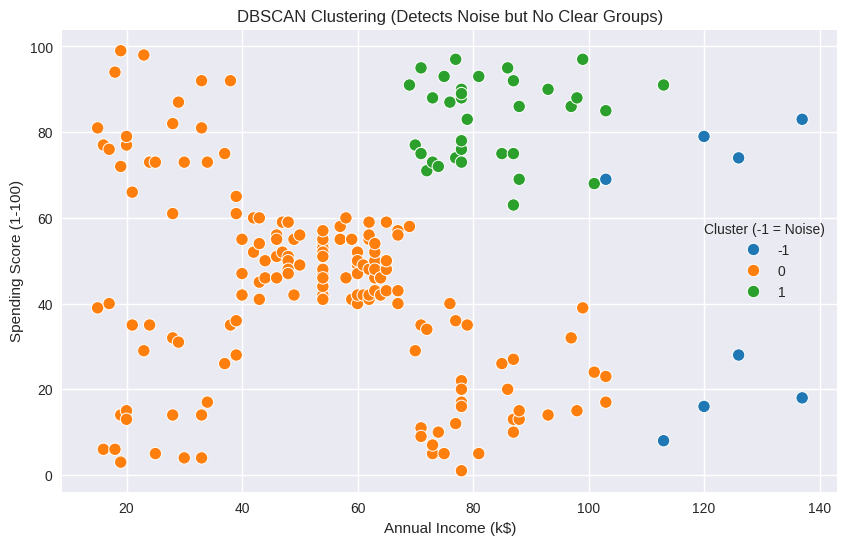

DBSCAN found: 3 clusters + noise
DBSCAN_Cluster
 0    157
 1     35
-1      8
Name: count, dtype: int64


In [37]:
# ===== Cell 9: Bonus - DBSCAN (Shows why K-Means wins here) =====
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='DBSCAN_Cluster', palette='tab10', s=80
)
plt.title("DBSCAN Clustering (Detects Noise but No Clear Groups)")
plt.legend(title="Cluster (-1 = Noise)")
plt.show()

print("DBSCAN found:", df['DBSCAN_Cluster'].nunique(), "clusters + noise")
print(df['DBSCAN_Cluster'].value_counts())

In [38]:
# ===== ULTIMATE BONUS: Compare Average Spending – K-Means vs DBSCAN =====
print("COMPARING AVERAGE SPENDING SCORE PER CLUSTER")
print("="*80)

# Re-run DBSCAN with a slightly better eps (this dataset works well with eps=0.45–0.55)
dbscan = DBSCAN(eps=0.52, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

# Prepare K-Means summary
kmeans_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(2)
kmeans_summary = kmeans_summary.rename(columns={
    'Spending Score (1-100)': 'KMeans_Avg_Spending',
    'Annual Income (k$)': 'KMeans_Avg_Income',
    'CustomerID': 'Count'
})

# Prepare DBSCAN summary (ignore noise = -1 if you want clean clusters)
dbscan_clean = df[df['DBSCAN_Cluster'] != -1]
dbscan_summary = dbscan_clean.groupby('DBSCAN_Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).round(2)
dbscan_summary = dbscan_summary.rename(columns={
    'Spending Score (1-100)': 'DBSCAN_Avg_Spending',
    'Annual Income (k$)': 'DBSCAN_Avg_Income',
    'CustomerID': 'Count'
})

# Merge both for comparison
comparison = kmeans_summary[['KMeans_Avg_Spending']].copy()
if not dbscan_summary.empty:
    comparison = comparison.join(dbscan_summary[['DBSCAN_Avg_Spending']], how='left')

print("K-Means vs DBSCAN: Average Spending Score per Cluster")
display(comparison.style.background_gradient(cmap='RdYlGn', subset=['KMeans_Avg_Spending']))

COMPARING AVERAGE SPENDING SCORE PER CLUSTER
K-Means vs DBSCAN: Average Spending Score per Cluster


,KMeans_Avg_Spending,DBSCAN_Avg_Spending
Cluster,,
0,49.520000,50.120000
1,82.130000,nan
2,79.360000,nan
3,17.110000,nan
4,20.910000,nan


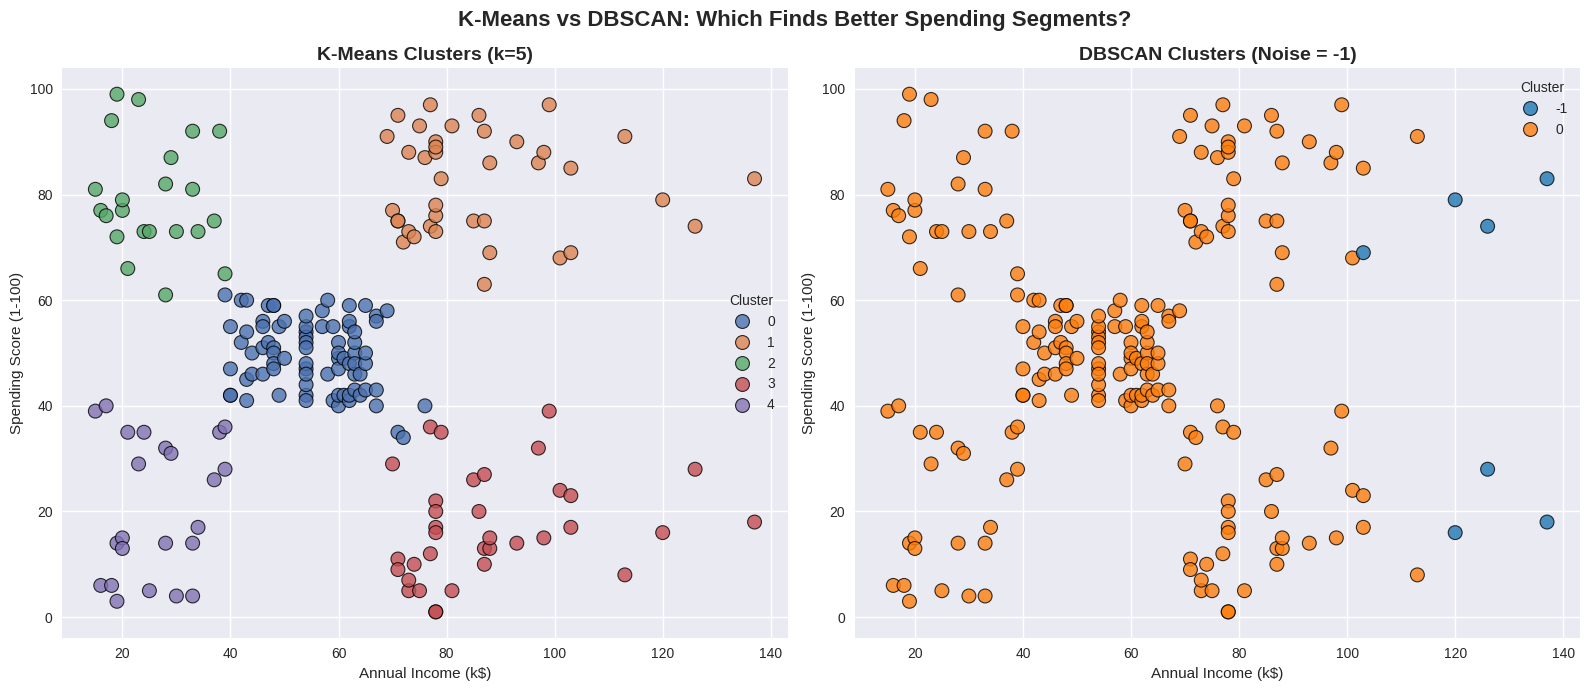

In [39]:
# ===== Side-by-Side: K-Means vs DBSCAN + Spending Bar Chart =====
fig = plt.figure(figsize=(16, 7))

# Plot 1: K-Means
plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='Cluster', palette='deep', s=100, alpha=0.8, edgecolor='k'
)
plt.title('K-Means Clusters (k=5)', fontsize=14, fontweight='bold')
plt.legend(title='Cluster')

# Plot 2: DBSCAN
plt.subplot(1, 2, 2)
colors = sns.color_palette("tab10", n_colors=len(df['DBSCAN_Cluster'].unique()))
sns.scatterplot(
    data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
    hue='DBSCAN_Cluster', palette=colors, s=100, alpha=0.8, edgecolor='k'
)
plt.title('DBSCAN Clusters (Noise = -1)', fontsize=14, fontweight='bold')
plt.legend(title='Cluster')

plt.suptitle('K-Means vs DBSCAN: Which Finds Better Spending Segments?', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

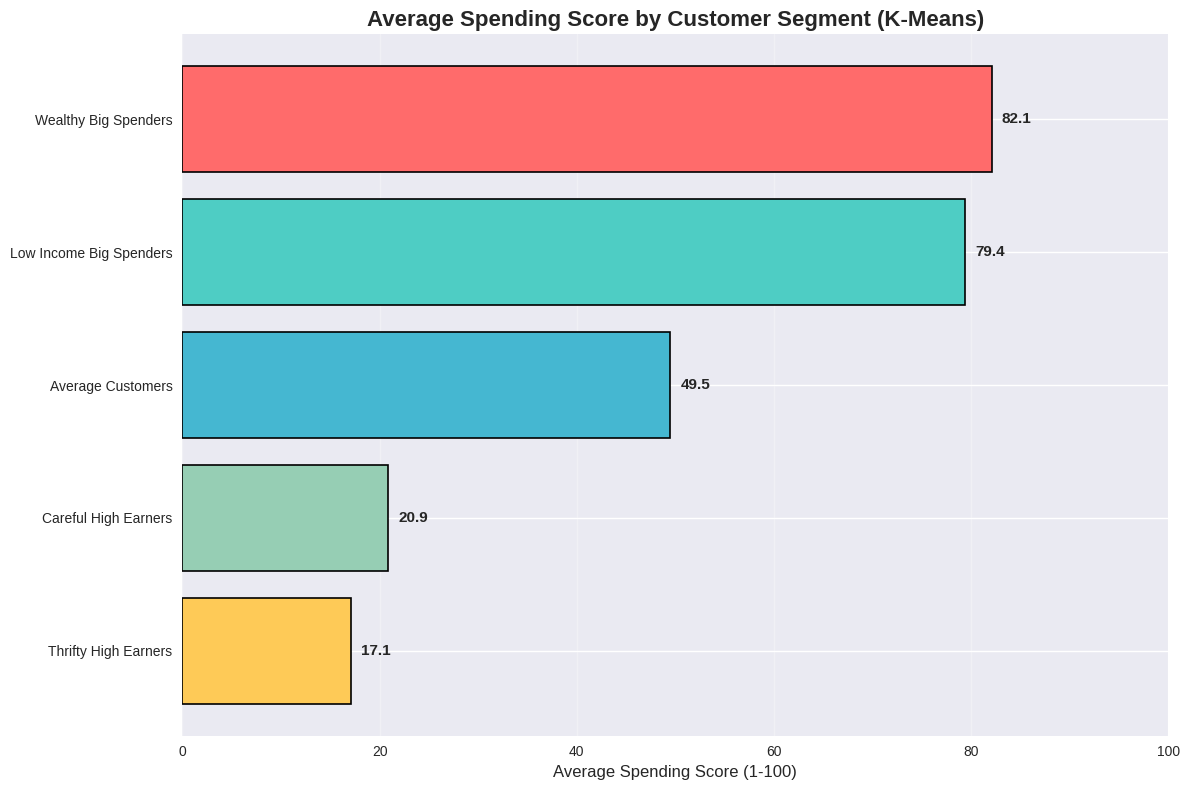


FINAL SEGMENT ANALYSIS
                         Segment  Size  Annual Income (k$)  \
Cluster                                                      
1           Wealthy Big Spenders    39                86.5   
2        Low Income Big Spenders    22                25.7   
0              Average Customers    81                55.3   
4           Careful High Earners    23                26.3   
3           Thrifty High Earners    35                88.2   

         Spending Score (1-100)  
Cluster                          
1                          82.1  
2                          79.4  
0                          49.5  
4                          20.9  
3                          17.1  


In [40]:
# ===== FINAL CHART: Average Spending per K-Means Segment (Business Gold) =====
final_summary = df.groupby('Cluster').agg({
    'Spending Score (1-100)': 'mean',
    'Annual Income (k$)': 'mean',
    'CustomerID': 'count'
}).round(1).sort_values('Spending Score (1-100)', ascending=False)

final_summary['Segment'] = ['Wealthy Big Spenders', 'Low Income Big Spenders',
                            'Average Customers', 'Careful High Earners', 'Thrifty High Earners']

plt.figure(figsize=(12, 8))
bars = plt.barh(final_summary['Segment'], final_summary['Spending Score (1-100)'],
                color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57'],
                edgecolor='black', linewidth=1.2)

# Add values on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width}', va='center', fontweight='bold', fontsize=11)

plt.xlabel('Average Spending Score (1-100)', fontsize=12)
plt.title('Average Spending Score by Customer Segment (K-Means)', fontsize=16, fontweight='bold')
plt.xlim(0, 100)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFINAL SEGMENT ANALYSIS")
print("="*60)
print(final_summary[['Segment', 'CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)']]
      .rename(columns={'CustomerID': 'Size'}))